# Chapter 2 - Exercise 8
Exploring the `College` data set (777 US universities and colleges).

In [1]:
import numpy as np
import pandas as pd
from matplotlib.pyplot import subplots

**(a)** Read the data into Python.

In [ ]:
college = pd.read_csv('College.csv')
college.head()

,Unnamed: 0,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
0,Univ_0,Yes,1660,1232,721,23,52,2885,537,7440,3300,450,2200,70,78,18.1,12,7041,60
1,Univ_1,Yes,2186,1924,512,16,29,2683,1227,12280,6450,750,1500,29,30,12.2,16,10527,56
2,Univ_2,Yes,1428,1097,336,22,50,1036,99,11250,3750,400,1165,53,66,12.9,30,8735,54
3,Univ_3,Yes,417,349,137,60,89,510,63,12960,5450,450,875,92,97,7.7,37,19016,59
4,Univ_4,Yes,193,146,55,16,44,249,869,7560,4120,800,1500,76,72,11.9,2,10922,15


**(b)** Fix the index so university names aren't treated as a data column.

In [ ]:
college2 = pd.read_csv('College.csv', index_col=0)
college3 = college.rename({'Unnamed: 0': 'College'}, axis=1)
college3 = college3.set_index('College')
college = college3
college.head()

,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
College,,,,,,,,,,,,,,,,,,
Univ_0,Yes,1660,1232,721,23,52,2885,537,7440,3300,450,2200,70,78,18.1,12,7041,60
Univ_1,Yes,2186,1924,512,16,29,2683,1227,12280,6450,750,1500,29,30,12.2,16,10527,56
Univ_2,Yes,1428,1097,336,22,50,1036,99,11250,3750,400,1165,53,66,12.9,30,8735,54
Univ_3,Yes,417,349,137,60,89,510,63,12960,5450,450,875,92,97,7.7,37,19016,59
Univ_4,Yes,193,146,55,16,44,249,869,7560,4120,800,1500,76,72,11.9,2,10922,15


**(c)** Numerical summary of the variables.

In [4]:
college.describe()

,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
count,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.00000
mean,3001.638353,2018.804376,779.972973,27.558559,55.796654,3699.907336,855.298584,10440.669241,4357.526384,549.380952,1340.642214,72.660232,79.702703,14.089704,22.743887,9660.171171,65.46332
std,3870.201484,2451.113971,929.176190,17.640364,19.804778,4850.420531,1522.431887,4023.016484,1096.696416,165.105360,677.071454,16.328155,14.722359,3.958349,12.391801,5221.768440,17.17771
min,81.000000,72.000000,35.000000,1.000000,9.000000,139.000000,1.000000,2340.000000,1780.000000,96.000000,250.000000,8.000000,24.000000,2.500000,0.000000,3186.000000,10.00000
25%,776.000000,604.000000,242.000000,15.000000,41.000000,992.000000,95.000000,7320.000000,3597.000000,470.000000,850.000000,62.000000,71.000000,11.500000,13.000000,6751.000000,53.00000
50%,1558.000000,1110.000000,434.000000,23.000000,54.000000,1707.000000,353.000000,9990.000000,4200.000000,500.000000,1200.000000,75.000000,82.000000,13.600000,21.000000,8377.000000,65.00000
75%,3624.000000,2424.000000,902.000000,35.000000,69.000000,4005.000000,967.000000,12925.000000,5050.000000,600.000000,1700.000000,85.000000,92.000000,16.500000,31.000000,10830.000000,78.00000
max,48094.000000,26330.000000,6392.000000,96.000000,100.000000,31643.000000,21836.000000,21700.000000,8124.000000,2340.000000,6800.000000,103.000000,100.000000,39.800000,64.000000,56233.000000,118.00000


**(d)** Scatterplot matrix of the first few columns.

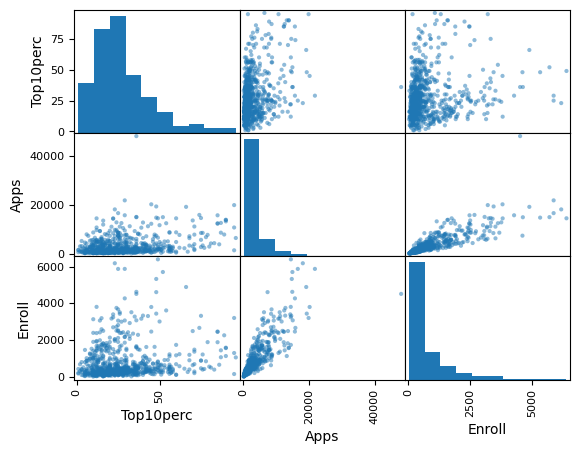

In [5]:
pd.plotting.scatter_matrix(college[['Top10perc', 'Apps', 'Enroll']]);

**(e)** Side-by-side boxplots of `Outstate` versus `Private`.

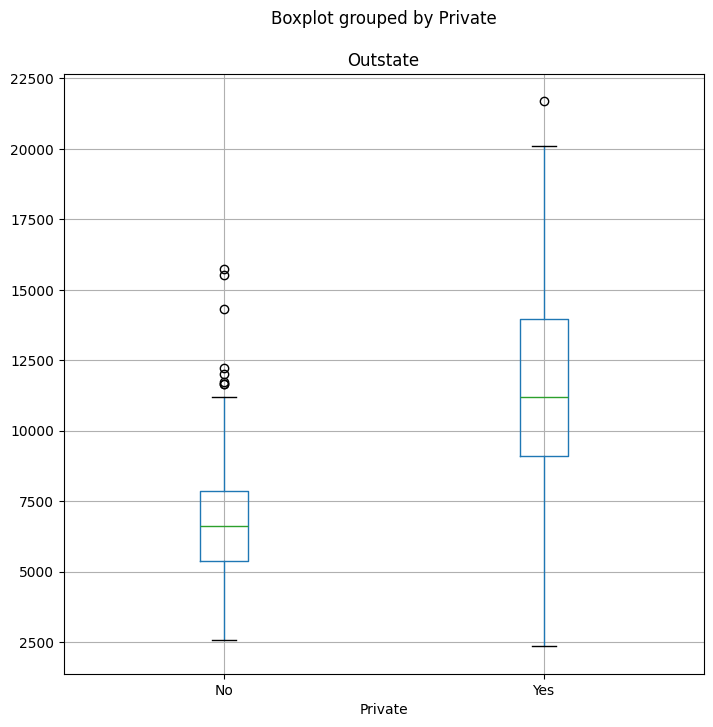

In [6]:
fig, ax = subplots(figsize=(8, 8))
college.boxplot('Outstate', by='Private', ax=ax);

**(f)** Create the `Elite` variable and compare `Outstate` versus `Elite`.

In [7]:
college['Elite'] = pd.cut(college['Top10perc'], [0, 50, 100], labels=['No', 'Yes'])  # bin at 50%
college['Elite'].value_counts()

Elite
No     699
Yes     78
Name: count, dtype: int64

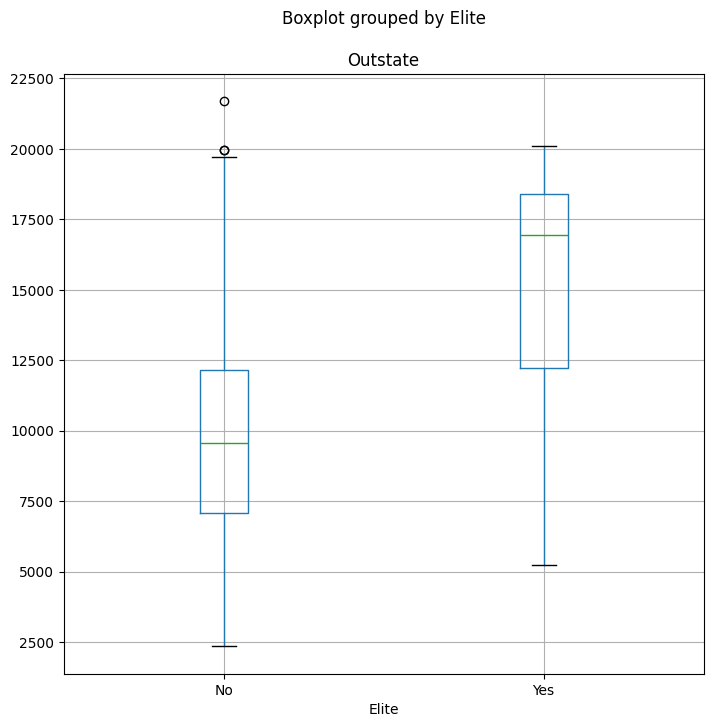

In [8]:
fig, ax = subplots(figsize=(8, 8))
college.boxplot('Outstate', by='Elite', ax=ax);

**(g)** Histograms of a few quantitative variables with different bin counts.

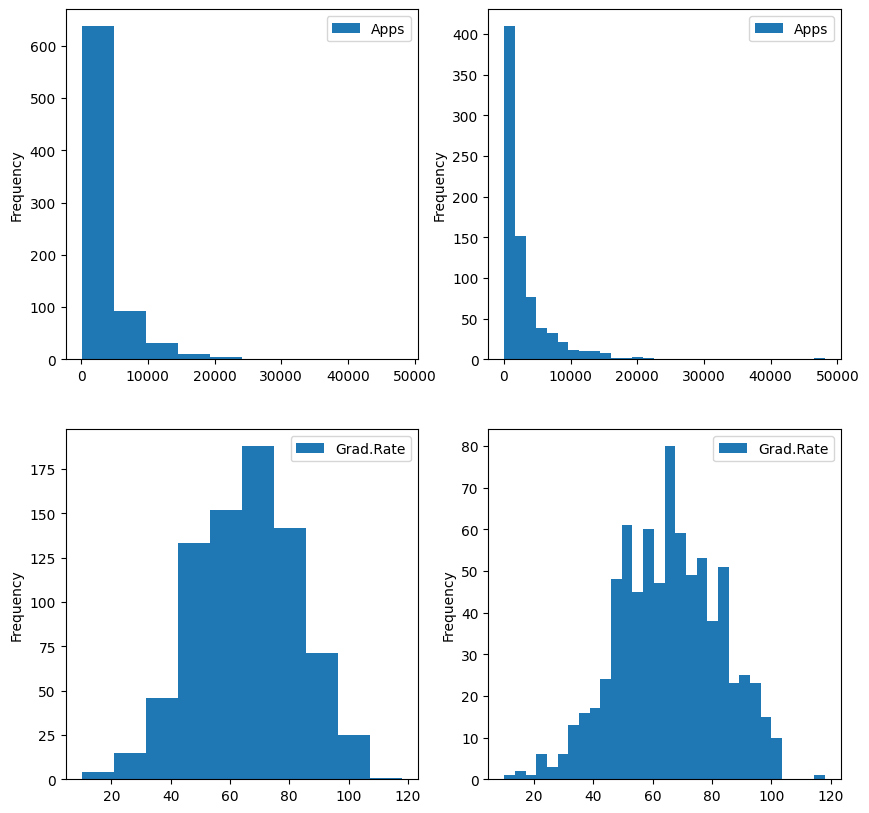

In [9]:
fig, axes = subplots(2, 2, figsize=(10, 10))
college.plot.hist(y='Apps', bins=10, ax=axes[0, 0])
college.plot.hist(y='Apps', bins=30, ax=axes[0, 1])
college.plot.hist(y='Grad.Rate', bins=10, ax=axes[1, 0])
college.plot.hist(y='Grad.Rate', bins=30, ax=axes[1, 1]);

**(h)** Further exploration.

In [10]:
college[['Apps', 'Accept', 'Enroll', 'Grad.Rate']].corr()  # check relationships among a few variables

,Apps,Accept,Enroll,Grad.Rate
Apps,1.000000,0.943451,0.846822,0.146755
Accept,0.943451,1.000000,0.911637,0.067313
Enroll,0.846822,0.911637,1.000000,-0.022341
Grad.Rate,0.146755,0.067313,-0.022341,1.000000


*Comment:* `Apps`, `Accept`, and `Enroll` are strongly correlated, as expected since more applications generally lead to more acceptances and enrollments. `Grad.Rate` shows a weaker relationship with these admissions variables, suggesting graduation outcomes depend more on other factors.